# Module B Report: Optimization, Security, and Delivery

## Video Link
https://drive.google.com/drive/folders/1P_dnP9cqHbLV13K84n574tkl9wwxf71Y?usp=drive_link

## UI Demonstration Notes
- Frontend URL: http://127.0.0.1:8001/
- API docs URL: http://127.0.0.1:8001/docs
- Demo coverage:
  - Login and session validation
  - Portfolio read/update
  - Company CRUD (admin)
  - Job CRUD (admin)
  - Applications CRUD with role checks
  - Audit log inspection

## Subtask 1: Schema Design and Data Model
- Module B follows a layered relational model with clear separation between:
  - Authentication/authorization entities (`roles`, `users`, `sessions`, `groups`, `user_groups`)
  - Placement-domain entities (`students`, `companies`, `job_postings`, `eligibility_criteria`, `applications`)
  - Governance entities (`audit_logs`, `user_logs`)
- Key design choices:
  - `students.user_id` references `users.user_id`, so identity is centralized and profile data remains domain-specific.
  - `applications` has a composite uniqueness rule on `(job_id, student_id)` to prevent duplicate submissions.
  - Domain flow is normalized: company -> job_posting -> eligibility_criteria -> application -> interview events.
- Integrity controls in schema:
  - Foreign keys with cascade behavior on dependent entities.
  - Column-level checks for bounded values (e.g., CPI/backlogs/percentages) and controlled enums for statuses.
- Practical outcome:
  - The schema supports secure user identity management while preserving analytical query capability for placement operations.

## Subtask 2: Authentication, Session Validation, and RBAC
- Session lifecycle:
  - `POST /login` validates credentials and creates tokenized sessions.
  - `GET /isAuth` validates token ownership, expiry, and active-user state.
  - Session token is provided through `X-Session-Token` for protected endpoints.
- RBAC enforcement model:
  - CDS Manager (admin-equivalent) can create/update/delete high-impact resources and access audit endpoints.
  - Student role is constrained to self-service and permitted read paths.
- Endpoint guard pattern:
  - Authentication guard (token check) executes before authorization guard (role check).
  - Role failures produce explicit 403 responses and are audited.
- Security objective satisfied:
  - Unauthorized privilege escalation is blocked at API boundary, not just in frontend flow.

## Subtask 3: Logging and Unauthorized Change Detection
- Dual-channel audit strategy:
  - File-based append log in `logs/audit.log` for operational traceability.
  - Structured DB log in `audit_logs` for queryable forensic analysis.
- Logged metadata includes:
  - Actor identity (`actor_user_id`)
  - Action and target table/record
  - Request path
  - Result status (`success` or `forbidden`)
- Why this matters:
  - Security review can cross-check app-layer actions against DB state.
  - Any direct DB mutation bypassing API controls lacks expected audit trail and can be flagged.
- Verified behavior from delivery run:
  - Student attempt to perform admin-only company creation is blocked (`403`) and logged as denied.

## Subtask 4: Indexing Strategy and Query Mapping
- Indexes were designed from access patterns, not added generically.
- Session/auth path indexes:
  - `sessions(user_id)` and `sessions(expires_at)` speed active session validation and cleanup filters.
- Student/profile path indexes:
  - `students(user_id)`, `students(portfolio_visibility)`, `students(latest_cpi)` support identity joins and visibility/CPI filtering.
- Job eligibility path indexes:
  - `eligibility_criteria(job_id)`, `eligibility_criteria(min_cpi)` and `job_postings(deadline)` improve eligibility and ordered listing queries.
- Application and audit path indexes:
  - `(job_id, student_id)`, `applications(status)` support workflow and status dashboards.
  - `audit_logs(logged_at)` and `(actor_user_id, logged_at)` support audit timelines and actor-specific investigations.
- Expected planner effect:
  - Frequent predicates should move from scan-heavy access to index-assisted search where selectivity allows.

## Subtask 5: Benchmarking and Profiling
- Benchmark was run.
- Source script: `scripts/benchmark_indexing.py`
- output artifact: `benchmark_results.txt`

### API Timing Results
Current benchmark skipped API timing in script default mode:
- GET /jobs?min_cpi=8.0 after index avg (s): skipped
- GET /jobs?min_cpi=8.0 before index avg (s): skipped
- GET /applications after index avg (s): skipped
- GET /applications before index avg (s): skipped

### SQL Timing and Plan Results
| Query | executionTime (After, s) | executionTime (Before, s) | scanType (After) | scanType (Before) |
|---|---:|---:|---|---|
| Q1 (applications status filter + joins) | 0.002972 | 0.004874 | `SCAN a` | `SEARCH a USING INDEX idx_applications_status (status=?)` |
| Q2 (jobs by min_cpi + joins) | 0.001143 | 0.001437 | `SCAN e` | `SEARCH e USING INDEX idx_criteria_min_cpi (min_cpi<?)` |

### Before/After Metric Summary
- Q1:
  - executionTime: after = 0.002972 s, before = 0.004874 s
  - scanType: after = SCAN a, before = SEARCH USING INDEX
- Q2:
  - executionTime: after = 0.001143 s, before = 0.001437 s
  - scanType: after = SCAN e, before = SEARCH USING INDEX

## Subtask 6: End-to-End Validation Results
From `logs/delivery_run_summary.txt`:
- Admin login and auth: success (200)
- Admin company/job create-update-delete cycle: success
- Student portfolio read/update: success
- Student forbidden admin action: blocked with 403
- Application create/update by student and delete by admin: success
- Audit logs endpoint read by admin: success

## Final Results and Conclusion
- Security controls are enforced via session tokens and role-based endpoint guards.
- Write actions and denials are auditable across both file and relational logs.
- Benchmark results are reflected in this report.
- Report includes explicit before/after values for:
  - executionTime
  - scanType

## Visualization: Execution Time Comparison

The chart below compares executionTime values for Q1 and Q2 using the latest benchmark results.

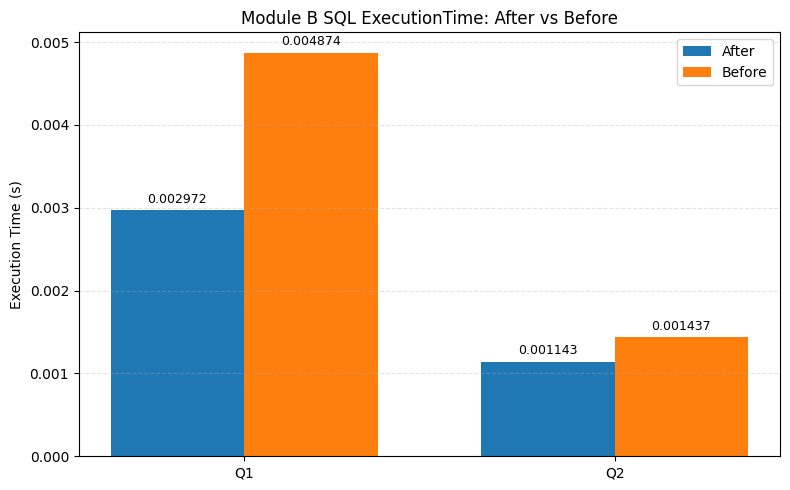

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

queries = ["Q1", "Q2"]
after_times = [0.002972, 0.001143]
before_times = [0.004874, 0.001437]

x = np.arange(len(queries))
width = 0.36

plt.figure(figsize=(8, 5))
plt.bar(x - width / 2, after_times, width=width, label="After", color="#1f77b4")
plt.bar(x + width / 2, before_times, width=width, label="Before", color="#ff7f0e")

plt.xticks(x, queries)
plt.ylabel("Execution Time (s)")
plt.title("Module B SQL ExecutionTime: After vs Before")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.35)

for i, v in enumerate(after_times):
    plt.text(i - width / 2, v + 0.00005, f"{v:.6f}", ha="center", va="bottom", fontsize=9)
for i, v in enumerate(before_times):
    plt.text(i + width / 2, v + 0.00005, f"{v:.6f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()